<a href="https://colab.research.google.com/github/So9912/Project6_Sofi/blob/main/proyecto__final_sofia_lopez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dashboard en Tableu:

https://drive.google.com/drive/folders/1v79aYMMmnRpE4qPEN6QseBMCLwL_Fgjl?usp=drive_link

## CallMeMaybe:
 Servicio de telefonía virtual está desarrollando una nueva función que brindará a los supervisores información sobre los operadores menos eficaces.

Objetivo: Identificar operadores ineficaces, lo cual ayudaría a optimizar la distribucion de llamadas, reducir costos y mejorar la satisfaccion del cliente.

Preprocesamiento

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

In [ ]:
dataset = pd.read_csv('https://raw.githubusercontent.com/HesusG/101010-data/refs/heads/main/datasets/telecom_dataset_us.csv')
clientes = pd.read_csv('https://raw.githubusercontent.com/HesusG/101010-data/refs/heads/main/datasets/telecom_clients_us.csv')

In [ ]:
display(dataset.head())
display(clientes.head())

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB


In [ ]:
clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB


Convertir tipo de datos a formato de fecha

In [ ]:
dataset['date'] = pd.to_datetime(dataset['date'], errors='coerce').dt.date
clientes['date_start'] = pd.to_datetime(clientes['date_start'], errors='coerce').dt.date

Revisamos si hay datos duplicados o ausentes

In [ ]:
def check_duplicates_and_missing(df, name):
    print(f"\nChecking {name} dataset:")
    print("Duplicated rows:", df.duplicated().sum())
    print("Missing values:\n", df.isnull().sum())

check_duplicates_and_missing(dataset, "Dataset")
check_duplicates_and_missing(clientes, "Clientes")


Checking Dataset dataset:
Duplicated rows: 4900
Missing values:
 user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64

Checking Clientes dataset:
Duplicated rows: 0
Missing values:
 user_id        0
tariff_plan    0
date_start     0
dtype: int64


Filtrar entre las llamadas entrantes y salientes para nuestros análisis.

In [ ]:
#Entrantes
llamadas_entrantes = dataset[dataset['direction'] == 'in']

#Salientes
llamadas_salientes = dataset[dataset['direction'] == 'out']


Calculamos el tiempo de espera

In [ ]:
dataset['waiting_time'] = dataset['total_call_duration'] - dataset['call_duration']
print(dataset.head())

   user_id        date direction internal  operator_id  is_missed_call  \
0   166377  2019-08-04        in    False          NaN            True   
1   166377  2019-08-05       out     True     880022.0            True   
2   166377  2019-08-05       out     True     880020.0            True   
3   166377  2019-08-05       out     True     880020.0           False   
4   166377  2019-08-05       out    False     880022.0            True   

   calls_count  call_duration  total_call_duration  waiting_time  
0            2              0                    4             4  
1            3              0                    5             5  
2            1              0                    1             1  
3            1             10                   18             8  
4            3              0                   25            25  


# Análisis exploratorio de datos:

In [ ]:
dataset = dataset.drop_duplicates().dropna()

def check_duplicates_and_missing(df, name):
    print(f"\nChecking {name} dataset:")
    print("Duplicated rows:", df.duplicated().sum())
    print("Missing values:\n", df.isnull().sum())

check_duplicates_and_missing(dataset, "Dataset")



Checking Dataset dataset:
Duplicated rows: 0
Missing values:
 user_id                0
date                   0
direction              0
internal               0
operator_id            0
is_missed_call         0
calls_count            0
call_duration          0
total_call_duration    0
waiting_time           0
dtype: int64


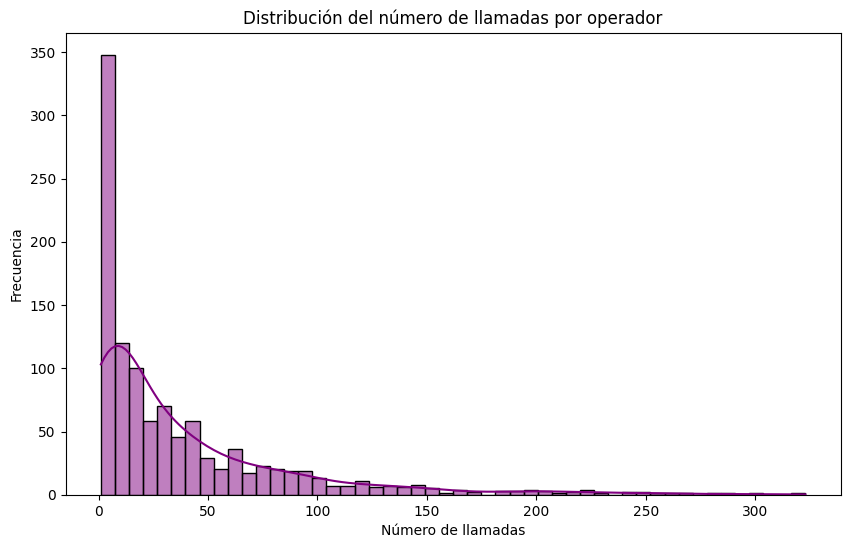

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(dataset['operator_id'].value_counts(), bins=50, kde=True, color='purple')
plt.title("Distribución del número de llamadas por operador")
plt.xlabel("Número de llamadas")
plt.ylabel("Frecuencia")
plt.show()

En la gráfica podemos observar un sesgo a la derecha (cola larga hacia la derecha), lo que indica que la mayoría de los operadores tienen un número relativamente bajo de llamadas, mientras que unos pocos operadores tienen un número muy alto de llamadas. La variabilidad en el número de llamadas por operador es alta, ya que algunos operadores atienden muy pocas llamadas (cerca de 50), mientras que otros atienden muchas más (hasta 350), un desbalance en la carga de trabajo entre los operadores.  La gráfica revela una distribución desigual en el número de llamadas por operador, con algunos operadores atendiendo un volumen significativamente mayor que otros.

In [ ]:
#Duración de las llamadas
incoming_calls = dataset[dataset['direction'] == 'in']
outgoing_calls = dataset[dataset['direction'] == 'out']

# Calcular la duración promedio de las llamadas entrantes y salientes
avg_duration_incoming = incoming_calls['call_duration'].mean()
avg_duration_outgoing = outgoing_calls['call_duration'].mean()

# Imprimir los resultados
print(f"\nDuración promedio -  llamadas entrantes: {avg_duration_incoming:.2f} seconds")
print(f"Duración promedio -  llamadas salientes: {avg_duration_outgoing:.2f} seconds")


# Promedio del tiempo de espera
avg_waiting_time_incoming = dataset[dataset['direction'] == 'in']['waiting_time'].mean()
avg_waiting_time_outgoing = dataset[dataset['direction'] == 'out']['waiting_time'].mean()

# Imprimir los resultados
print(f"\nTiempo de espera promedio -  llamadas entrantes: {avg_waiting_time_incoming:.2f} seconds")
print(f"Tiempo de espera promedio -  llamadas salientes:: {avg_waiting_time_outgoing:.2f} seconds")


Duración promedio -  llamadas entrantes: 750.67 seconds
Duración promedio -  llamadas salientes: 1125.46 seconds

Tiempo de espera promedio -  llamadas entrantes: 97.20 seconds
Tiempo de espera promedio -  llamadas salientes:: 406.82 seconds


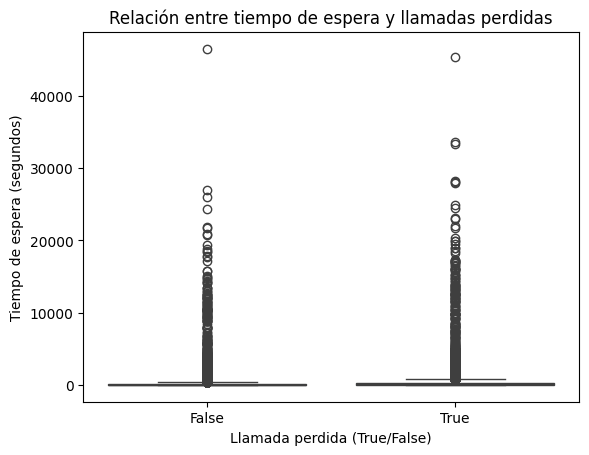

In [ ]:
# Gráfico de caja para comparar el tiempo de espera entre llamadas perdidas y no perdidas
sns.boxplot(x='is_missed_call', y='waiting_time', data=dataset)
plt.title('Relación entre tiempo de espera y llamadas perdidas')
plt.xlabel('Llamada perdida (True/False)')
plt.ylabel('Tiempo de espera (segundos)')
plt.show()

En la gráfica anterior podemos vercómo los valores son muy similares entre qué tanto influye el tiempo de espera con que la llamada se haya perdido, aunque po muy poco (true) se observa que sí influye, ya que tiene un valor un poco mayor.

In [ ]:
# Calcular la correlación entre el tiempo de espera y si la llamada fue perdida o no
correlation = dataset[['waiting_time', 'is_missed_call']].corr().loc['waiting_time', 'is_missed_call']
print(f"\nCorrelación entre tiempo de espera y llamadas perdidas: {correlation:.2f}")


Correlación entre tiempo de espera y llamadas perdidas: 0.08


Adicional el valor de correlación sugiere que no hay una tendencia clara que indique que un mayor tiempo de espera esté asociado con un aumento en las llamadas perdidas, o viceversa.
El hecho de que los clientes esperen más tiempo no parece influir significativamente en que las llamadas se pierdan. Esto podría deberse a que los clientes están dispuestos a esperar sin colgar, o a que otros factores (como la calidad de la atención) son más relevantes para determinar si una llamada se pierde.

# Plan de acción

Distribución de llamadas perdidas por operador

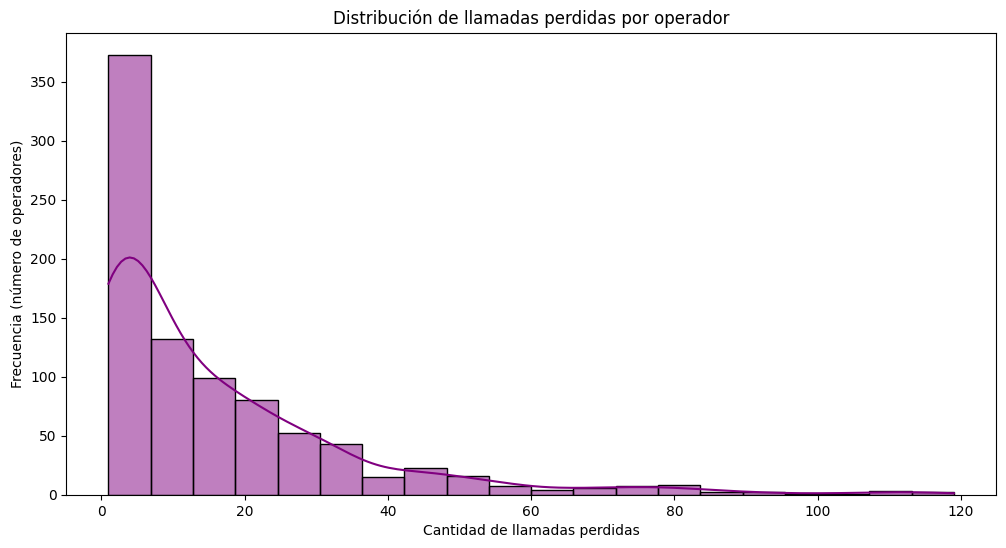

In [ ]:
# Filtrar solo las llamadas perdidas
missed_calls = dataset[dataset['is_missed_call'] == True]

# Contar la cantidad de llamadas perdidas por operador
missed_calls_by_operator = missed_calls['operator_id'].value_counts()

# Crear el histograma
plt.figure(figsize=(12, 6))
sns.histplot(missed_calls_by_operator, bins=20, kde=True, color='purple')  # Cambia el color a morado
plt.title('Distribución de llamadas perdidas por operador')
plt.xlabel('Cantidad de llamadas perdidas')
plt.ylabel('Frecuencia (número de operadores)')
plt.show()

La gráfica revela un sesgo a la derecha (cola larga hacia la derecha), lo que indica que la mayoría de los operadores tienen un número relativamente bajo de llamadas perdidas, mientras que unos pocos operadores tienen un número muy alto de llamadas perdidas.El pico de la distribución está alrededor de 0 a 20 llamadas perdidas, lo que significa que la mayoría de los operadores tienen entre 0 y 20 llamadas perdidas.La variabilidad en el número de llamadas perdidas por operador es alta, ya que algunos operadores tienen muy pocas llamadas perdidas (cerca de 0), mientras que otros tienen muchas más (hasta 140).

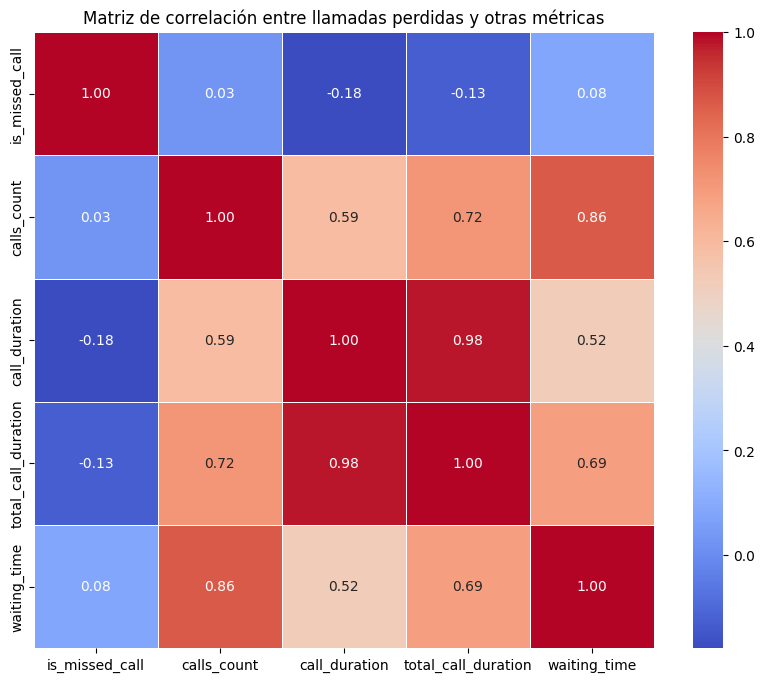

In [ ]:
# Convertir la columna 'is_missed_call' a valores numéricos (1 para True, 0 para False)
dataset['is_missed_call'] = dataset['is_missed_call'].astype(int)

# Seleccionar las columnas numéricas para el análisis de correlación
numeric_columns = ['is_missed_call', 'calls_count', 'call_duration', 'total_call_duration', 'waiting_time']
correlation_data = dataset[numeric_columns]

# Calcular la matriz de correlación
correlation_matrix = correlation_data.corr()

# Visualizar la matriz de correlación con un heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de correlación entre llamadas perdidas y otras métricas')
plt.show()

Las llamadas perdidas no están fuertemente correlacionadas con el tiempo de espera ni con el número de llamadas. Esto sugiere que otros factores (como la calidad de la atención o la congestión del sistema) pueden ser más relevantes para explicar las llamadas perdidas.
El tiempo de espera está fuertemente correlacionado con el número de llamadas (calls_count), lo que sugiere que la congestión del sistema puede ser un problema. Para reducir el tiempo de espera, se podrían implementar estrategias como:
Aumentar el número de operadores en horas pico.
Mejorar la distribución de la carga de trabajo.
La duración de la llamada está fuertemente correlacionada con la duración total de la llamada, lo cual es esperado. Sin embargo, también está moderadamente correlacionada con el número de llamadas, lo que sugiere que los operadores con más llamadas tienden a tener llamadas más largas. Esto podría indicar que necesitan más apoyo o capacitación para manejar las llamadas de manera más eficiente.
La duración total de la llamada está fuertemente correlacionada con el número de llamadas y moderadamente correlacionada con el tiempo de espera. Esto refuerza la idea de que la congestión del sistema puede estar afectando tanto el tiempo de espera como la duración total de las llamadas.

In [ ]:
significant_correlations = correlation_matrix[(correlation_matrix > 0.5) | (correlation_matrix < -0.5)]
print(significant_correlations)

                     is_missed_call  calls_count  call_duration  \
is_missed_call                  1.0          NaN            NaN   
calls_count                     NaN     1.000000       0.592257   
call_duration                   NaN     0.592257       1.000000   
total_call_duration             NaN     0.715263       0.977881   
waiting_time                    NaN     0.864592       0.524072   

                     total_call_duration  waiting_time  
is_missed_call                       NaN           NaN  
calls_count                     0.715263      0.864592  
call_duration                   0.977881      0.524072  
total_call_duration             1.000000      0.690616  
waiting_time                    0.690616      1.000000  


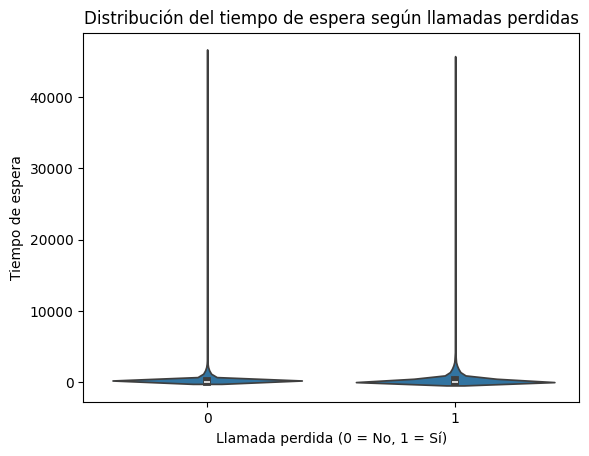

In [ ]:
sns.violinplot(x='is_missed_call', y='waiting_time', data=dataset, inner='box')
plt.title('Distribución del tiempo de espera según llamadas perdidas')
plt.xlabel('Llamada perdida (0 = No, 1 = Sí)')
plt.ylabel('Tiempo de espera')
plt.show()

La mayoría de los tiempos de espera están concentrados en valores bajos, cerca de 0.
Existen valores extremadamente altos que generan colas largas en el gráfico, lo que sugiere la presencia de valores atípicos.
No parece haber una diferencia significativa en la forma de las distribuciones entre ambos grupos.

Relación entre tiempos y número de llamadas por operador

In [ ]:
# Agrupar los datos por operador y calcular métricas agregadas
operator_metrics = dataset.groupby('operator_id').agg(
    calls_count=('calls_count', 'sum'),  # Número total de llamadas por operador
    avg_call_duration=('call_duration', 'mean'),  # Duración promedio de las llamadas
    avg_total_call_duration=('total_call_duration', 'mean'),  # Duración total promedio
    avg_waiting_time=('waiting_time', 'mean')  # Tiempo de espera promedio
).reset_index()

# Mostrar las métricas calculadas
print(operator_metrics.head())

   operator_id  calls_count  avg_call_duration  avg_total_call_duration  \
0     879896.0          930         545.829060               650.743590   
1     879898.0         7312        1138.889381              1598.579646   
2     880020.0           45         112.250000               126.250000   
3     880022.0          197         216.385714               270.357143   
4     880026.0         2232         842.450549               964.428571   

   avg_waiting_time  
0        104.914530  
1        459.690265  
2         14.000000  
3         53.971429  
4        121.978022  


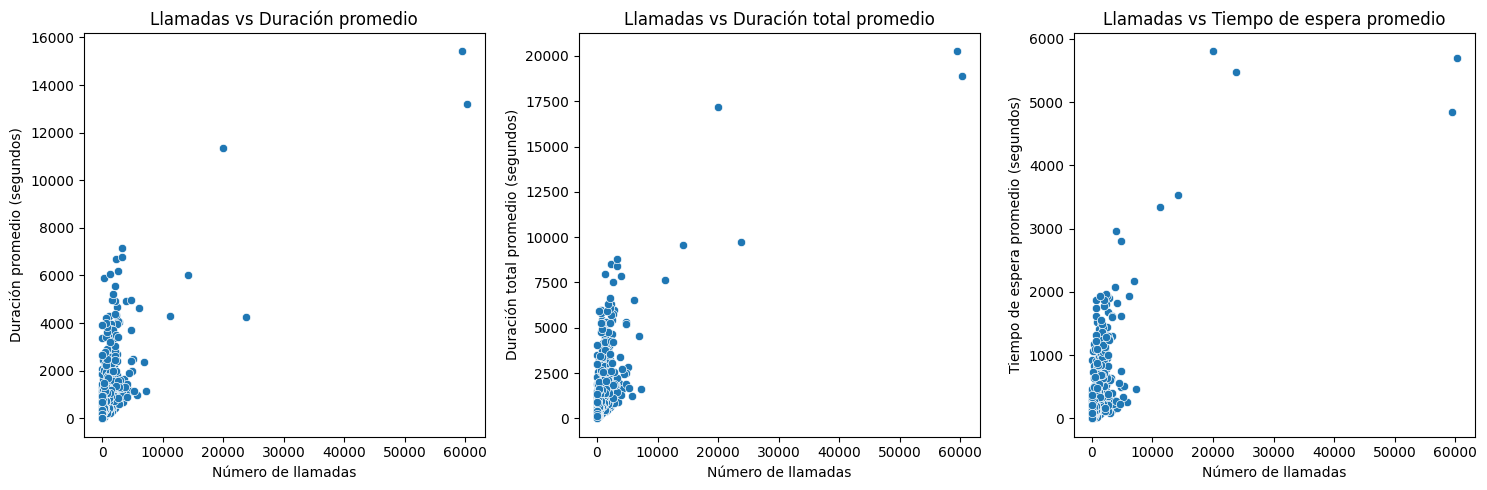

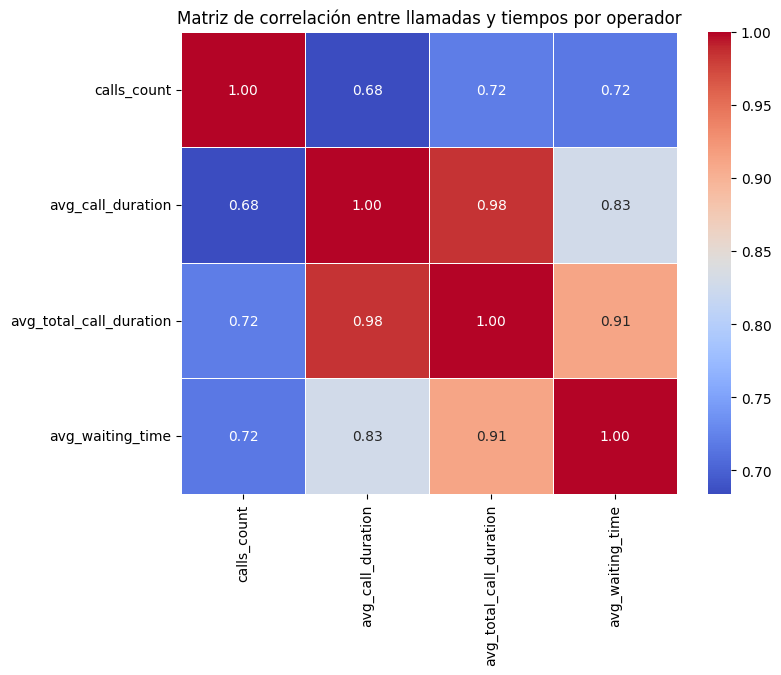

In [ ]:
# Visualizar la relación entre el número de llamadas y los tiempos promedio
plt.figure(figsize=(15, 5))

# Gráfico 1: Número de llamadas vs Duración promedio de las llamadas
plt.subplot(1, 3, 1)
sns.scatterplot(x='calls_count', y='avg_call_duration', data=operator_metrics)
plt.title('Llamadas vs Duración promedio')
plt.xlabel('Número de llamadas')
plt.ylabel('Duración promedio (segundos)')

# Gráfico 2: Número de llamadas vs Duración total promedio
plt.subplot(1, 3, 2)
sns.scatterplot(x='calls_count', y='avg_total_call_duration', data=operator_metrics)
plt.title('Llamadas vs Duración total promedio')
plt.xlabel('Número de llamadas')
plt.ylabel('Duración total promedio (segundos)')

# Gráfico 3: Número de llamadas vs Tiempo de espera promedio
plt.subplot(1, 3, 3)
sns.scatterplot(x='calls_count', y='avg_waiting_time', data=operator_metrics)
plt.title('Llamadas vs Tiempo de espera promedio')
plt.xlabel('Número de llamadas')
plt.ylabel('Tiempo de espera promedio (segundos)')

plt.tight_layout()
plt.show()

# Calcular la correlación entre el número de llamadas y los tiempos promedio
correlation_matrix = operator_metrics[['calls_count', 'avg_call_duration', 'avg_total_call_duration', 'avg_waiting_time']].corr()

# Visualizar la matriz de correlación
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de correlación entre llamadas y tiempos por operador')
plt.show()

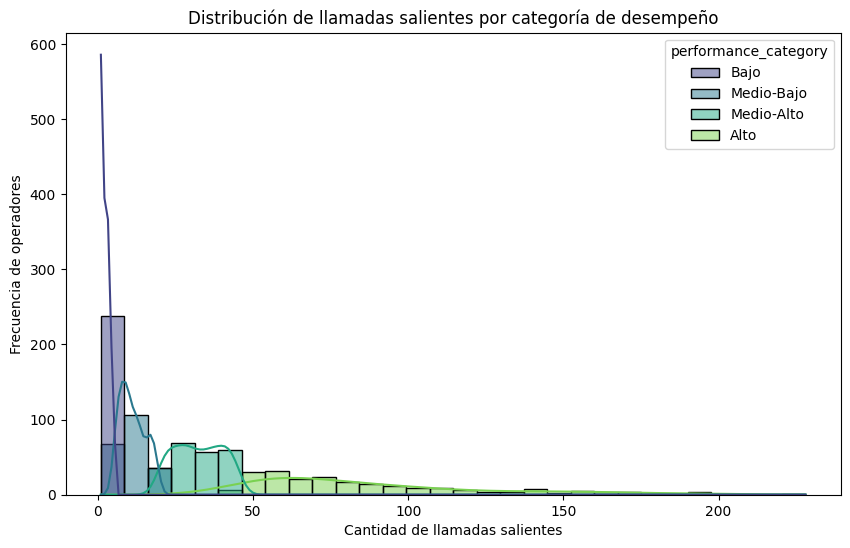

In [ ]:
# Definir categorías basadas en cuartiles (25%, 50%, 75%)
outgoing_calls_by_operator['performance_category'] = pd.qcut(
    outgoing_calls_by_operator['outgoing_calls_count'],
    q=4,
    labels=['Bajo', 'Medio-Bajo', 'Medio-Alto', 'Alto']
)

plt.figure(figsize=(10, 6))
sns.histplot(
    data=outgoing_calls_by_operator,
    x='outgoing_calls_count',
    hue='performance_category',
    bins=30,
    kde=True,
    palette='viridis'
)
plt.title('Distribución de llamadas salientes por categoría de desempeño')
plt.xlabel('Cantidad de llamadas salientes')
plt.ylabel('Frecuencia de operadores')
plt.show()

La gráfica muestra la distribución de la cantidad de llamadas salientes por operador, agrupados en cuatro categorías de desempeño (Bajo, Medio-Bajo, Medio-Alto y Alto). La mayoría de los operadores tienen pocas llamadas, con una alta concentración en la categoría "Bajo". A medida que aumenta la cantidad de llamadas, la frecuencia de operadores disminuye, formando una distribución sesgada a la derecha. Los operadores de alto desempeño son menos frecuentes pero tienen un mayor volumen de llamadas. Esto sugiere que la mayoría de los operadores hacen pocas llamadas, mientras que un pequeño grupo maneja una carga significativamente mayor.

Combinar la proporción de llamadas perdidas y tiempo de espera

<ipython-input-59-702f1c9939f1>:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  operator_performance_few_outgoing['missed_calls_category'] = pd.qcut(
<ipython-input-59-702f1c9939f1>:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  operator_performance_few_outgoing['waiting_time_category'] = pd.qcut(


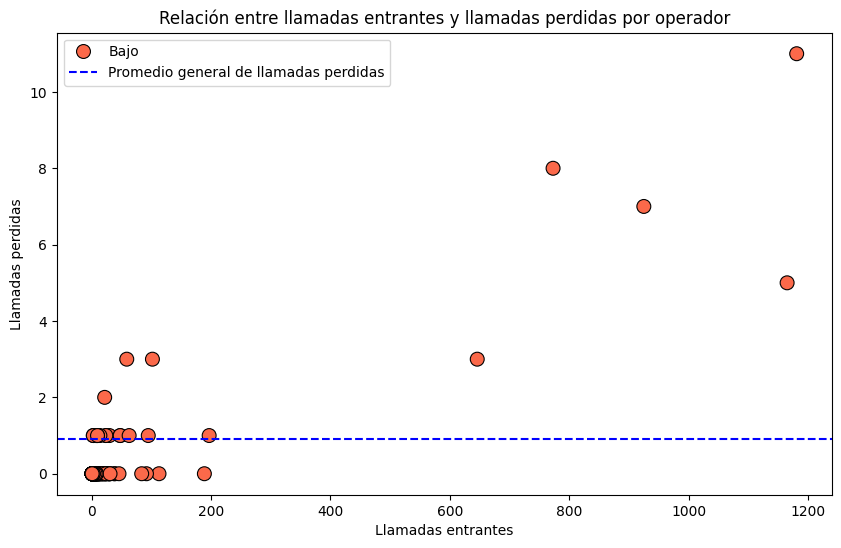

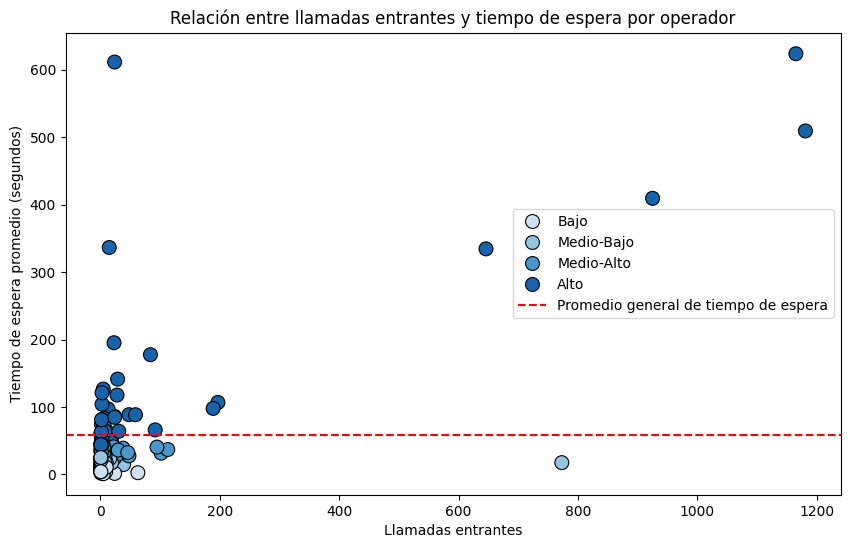

In [ ]:
# Identificar operadores con pocas llamadas salientes
threshold = 10  # Umbral de llamadas salientes
operators_few_outgoing = outgoing_calls_by_operator[outgoing_calls_by_operator['outgoing_calls_count'] < threshold]

# Analizar el desempeño de estos operadores en llamadas entrantes
incoming_calls = dataset[dataset['direction'] == 'in']

# Calcular métricas de desempeño
operator_performance = incoming_calls.groupby('operator_id').agg(
    incoming_calls_count=('calls_count', 'sum'),
    missed_calls_count=('is_missed_call', 'sum'),
    avg_waiting_time=('waiting_time', 'mean')
).reset_index()

# Filtrar operadores con pocas llamadas salientes
operator_performance_few_outgoing = operator_performance[
    operator_performance['operator_id'].isin(operators_few_outgoing['operator_id'])
]

# Comparar con los promedios generales
avg_missed_calls = operator_performance['missed_calls_count'].mean()
avg_waiting_time = operator_performance['avg_waiting_time'].mean()

# Agrupar operadores por llamadas perdidas (corrección de bins y etiquetas)
unique_missed_calls = operator_performance_few_outgoing['missed_calls_count'].nunique()

if unique_missed_calls > 1:
    q = min(4, unique_missed_calls)
    bins = pd.qcut(operator_performance_few_outgoing['missed_calls_count'], q=q, retbins=True, duplicates='drop')[1]
    labels = ['Bajo', 'Medio-Bajo', 'Medio-Alto', 'Alto'][:len(bins)-1]
    operator_performance_few_outgoing['missed_calls_category'] = pd.qcut(
        operator_performance_few_outgoing['missed_calls_count'],
        q=q,
        labels=labels,
        duplicates='drop'
    )
else:
    operator_performance_few_outgoing['missed_calls_category'] = 'Única categoría'

# Agrupar operadores por tiempo de espera (corrección de bins y etiquetas)
unique_waiting_time = operator_performance_few_outgoing['avg_waiting_time'].nunique()

if unique_waiting_time > 1:
    q = min(4, unique_waiting_time)
    bins = pd.qcut(operator_performance_few_outgoing['avg_waiting_time'], q=q, retbins=True, duplicates='drop')[1]
    labels = ['Bajo', 'Medio-Bajo', 'Medio-Alto', 'Alto'][:len(bins)-1]
    operator_performance_few_outgoing['waiting_time_category'] = pd.qcut(
        operator_performance_few_outgoing['avg_waiting_time'],
        q=q,
        labels=labels,
        duplicates='drop'
    )
else:
    operator_performance_few_outgoing['waiting_time_category'] = 'Única categoría'

# Diagrama de dispersión de llamadas perdidas vs. llamadas entrantes con color por categoría
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=operator_performance_few_outgoing,
    x='incoming_calls_count',
    y='missed_calls_count',
    hue='missed_calls_category',
    palette='Reds',
    s=100,
    edgecolor='black'
)
plt.axhline(avg_missed_calls, color='blue', linestyle='--', label='Promedio general de llamadas perdidas')
plt.title('Relación entre llamadas entrantes y llamadas perdidas por operador')
plt.xlabel('Llamadas entrantes')
plt.ylabel('Llamadas perdidas')
plt.legend()
plt.show()

# Diagrama de dispersión de tiempo de espera vs. llamadas entrantes con color por categoría
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=operator_performance_few_outgoing,
    x='incoming_calls_count',
    y='avg_waiting_time',
    hue='waiting_time_category',
    palette='Blues',
    s=100,
    edgecolor='black'
)
plt.axhline(avg_waiting_time, color='red', linestyle='--', label='Promedio general de tiempo de espera')
plt.title('Relación entre llamadas entrantes y tiempo de espera por operador')
plt.xlabel('Llamadas entrantes')
plt.ylabel('Tiempo de espera promedio (segundos)')
plt.legend()
plt.show()

En la gráfica se muestra cómo los operadores manejan las llamadas entrantes y cuántas de ellas terminan en llamadas perdidas, la mayoría de los operadores tienen pocas llamadas entrantes y pocas llamadas perdidas.
La mayoría de los puntos se agrupan en la parte inferior izquierda, lo que indica que hay operadores con pocas llamadas entrantes y un bajo número de llamadas perdidas, sin embargo, algunos operadores con un alto volumen de llamadas (más de 600) presentan una mayor cantidad de llamadas perdidas, lo que sugiere que pueden estar sobrecargados.

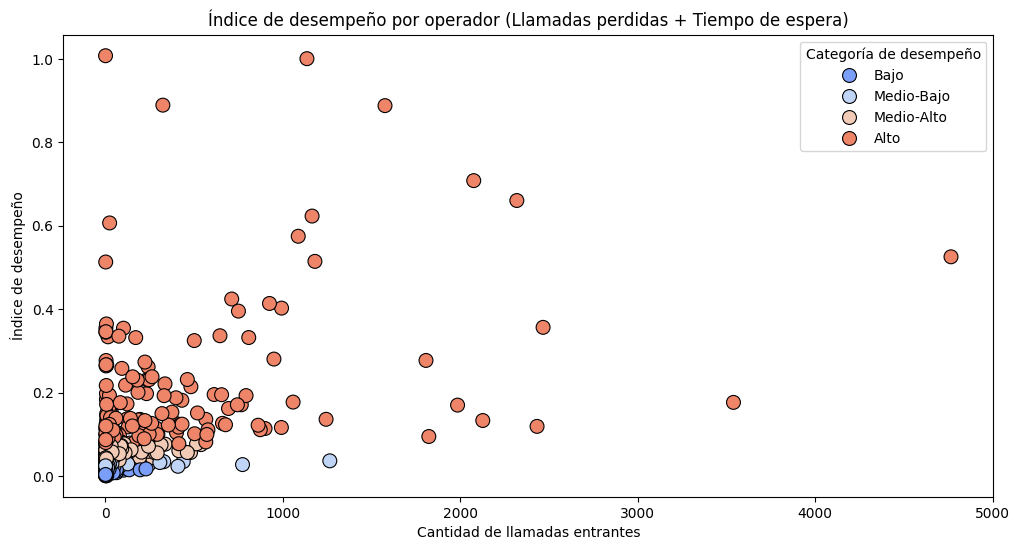

In [ ]:
# Calcular la proporción de llamadas perdidas y el tiempo de espera promedio por operador
operator_performance = incoming_calls.groupby('operator_id').agg(
    incoming_calls_count=('calls_count', 'sum'),
    missed_calls_count=('is_missed_call', 'sum'),
    avg_waiting_time=('waiting_time', 'mean')
).reset_index()

# Calcular la proporción de llamadas perdidas
operator_performance['missed_calls_ratio'] = (
    operator_performance['missed_calls_count'] / operator_performance['incoming_calls_count']
)

# Normalizar el tiempo de espera
max_waiting_time = operator_performance['avg_waiting_time'].max()
operator_performance['normalized_waiting_time'] = (
    operator_performance['avg_waiting_time'] / max_waiting_time
)

# Crear el índice compuesto de desempeño
operator_performance['performance_index'] = (
    operator_performance['missed_calls_ratio'] + operator_performance['normalized_waiting_time']
)

# Agrupar operadores en categorías según su índice de desempeño
num_unique_performance = operator_performance['performance_index'].nunique()

if num_unique_performance > 1:
    q = min(4, num_unique_performance)
    bins = pd.qcut(operator_performance['performance_index'], q=q, retbins=True, duplicates='drop')[1]
    labels = ['Bajo', 'Medio-Bajo', 'Medio-Alto', 'Alto'][:len(bins)-1]
    operator_performance['performance_category'] = pd.qcut(
        operator_performance['performance_index'],
        q=q,
        labels=labels,
        duplicates='drop'
    )
else:
    operator_performance['performance_category'] = 'Única categoría'

# Visualización con diagrama de dispersión en lugar de gráfico de barras saturado
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=operator_performance,
    x='incoming_calls_count',
    y='performance_index',
    hue='performance_category',
    palette='coolwarm',
    s=100,
    edgecolor='black'
)
plt.title('Índice de desempeño por operador (Llamadas perdidas + Tiempo de espera)')
plt.xlabel('Cantidad de llamadas entrantes')
plt.ylabel('Índice de desempeño')
plt.legend(title='Categoría de desempeño')
plt.show()

Los operadores están agrupados en categorías de desempeño (Bajo, Medio-Bajo, Medio-Alto y Alto), el índice de desempeño combina la proporción de llamadas perdidas y el tiempo de espera promedio, por lo que valores más altos indican peor desempeño.

La mayoría de los operadores tienen pocas llamadas entrantes y un índice de desempeño bajo, lo que sugiere que gestionan bien sus llamadas, a medida que aumenta el número de llamadas entrantes, algunos operadores muestran un desempeño significativamente peor (índice alto).

Los operadores con índice bajo están mayormente concentrados en la parte inferior izquierda, indicando buen desempeño con pocas llamadas entrantes.
Los operadores con índice alto están dispersos en toda la gráfica, lo que sugiere que algunos tienen problemas en la gestión de llamadas, especialmente cuando el volumen de llamadas aumenta.

Hay operadores con índice de desempeño muy alto (> 0.5), lo que sugiere que tienen una combinación de muchas llamadas perdidas y largos tiempos de espera.
Estos casos deberían analizarse para determinar si el problema se debe a sobrecarga, falta de capacitación o deficiencias en la infraestructura.

performance_category
Bueno      739
Regular     10
Malo         5
Name: count, dtype: int64

Resumen por categoría de desempeño:
  performance_category  incoming_calls_count  missed_calls_count  \
0                Bueno            102.104195            0.837618   
1                 Malo           1022.600000            2.800000   
2              Regular           1317.400000            5.100000   

   avg_waiting_time  missed_calls_ratio  performance_index  
0         48.066618            0.012475           0.060190  
1        701.769102            0.202374           0.899005  
2        476.121783            0.053565           0.526201  


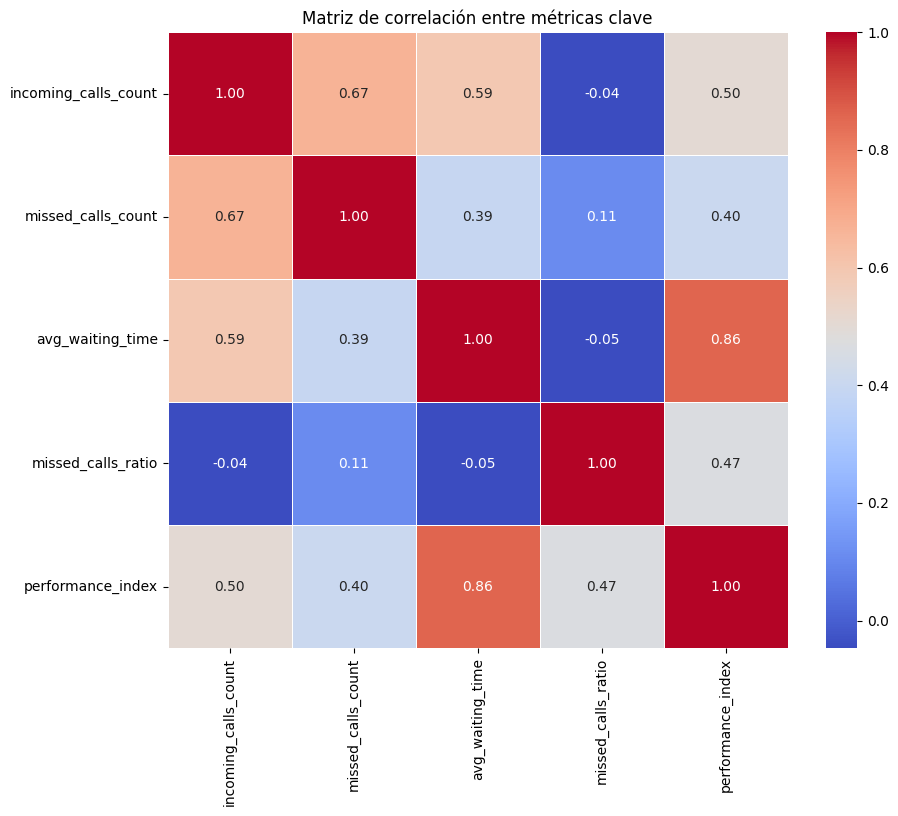

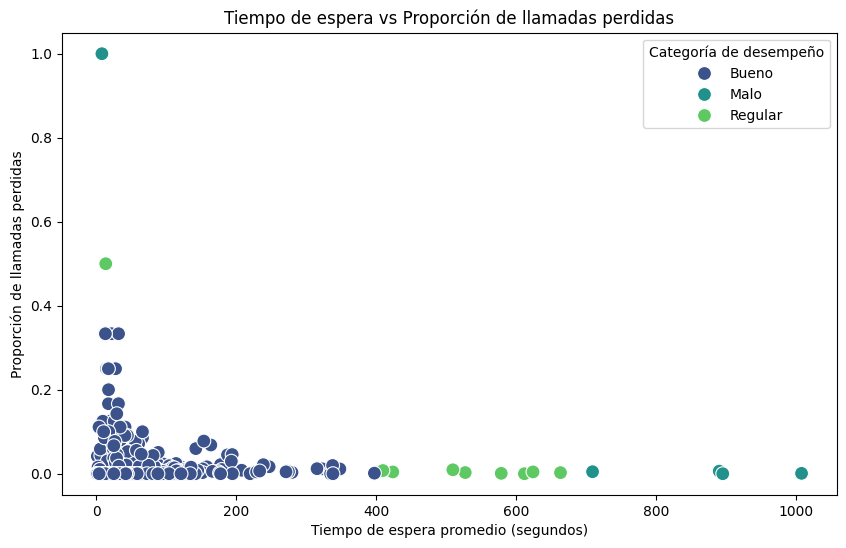

<ipython-input-26-905e1a2295a8>:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


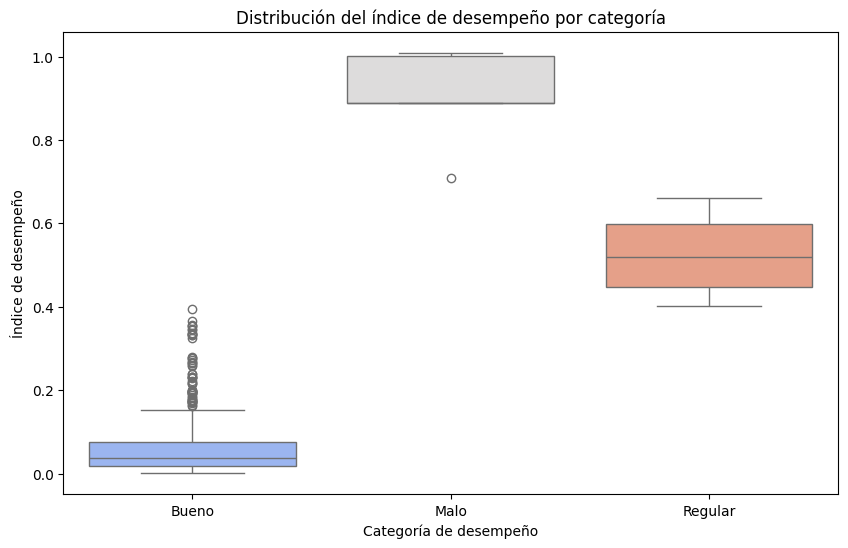

In [ ]:
# 1. Clasificar operadores por desempeño
# Definir categorías basadas en el índice de desempeño
def categorize_performance(index):
    if index <= 0.4:
        return "Bueno"
    elif index <= 0.7:
        return "Regular"
    else:
        return "Malo"

operator_performance['performance_category'] = operator_performance['performance_index'].apply(categorize_performance)

# Mostrar la distribución de categorías
print(operator_performance['performance_category'].value_counts())

# 2. Analizar características comunes por categoría
# Agrupar por categoría y calcular promedios
category_summary = operator_performance.groupby('performance_category').agg({
    'incoming_calls_count': 'mean',
    'missed_calls_count': 'mean',
    'avg_waiting_time': 'mean',
    'missed_calls_ratio': 'mean',
    'performance_index': 'mean'
}).reset_index()

print("\nResumen por categoría de desempeño:")
print(category_summary)

# 3. Identificar correlaciones entre métricas clave
# Calcular la matriz de correlación
correlation_matrix = operator_performance[['incoming_calls_count', 'missed_calls_count', 'avg_waiting_time', 'missed_calls_ratio', 'performance_index']].corr()

# Visualizar la matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de correlación entre métricas clave')
plt.show()

# 4. Visualizar patrones con gráficos
# Gráfico de dispersión: Tiempo de espera vs Proporción de llamadas perdidas
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='avg_waiting_time',
    y='missed_calls_ratio',
    hue='performance_category',
    data=operator_performance,
    palette='viridis',
    s=100
)
plt.title('Tiempo de espera vs Proporción de llamadas perdidas')
plt.xlabel('Tiempo de espera promedio (segundos)')
plt.ylabel('Proporción de llamadas perdidas')
plt.legend(title='Categoría de desempeño')
plt.show()

# Gráfico de caja: Índice de desempeño por categoría
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='performance_category',
    y='performance_index',
    data=operator_performance,
    palette='coolwarm'
)
plt.title('Distribución del índice de desempeño por categoría')
plt.xlabel('Categoría de desempeño')
plt.ylabel('Índice de desempeño')
plt.show()

Las llamadas perdidas no están fuertemente correlacionadas con el tiempo de espera ni con el número de llamadas. Esto sugiere que otros factores (como la calidad de la atención o la congestión del sistema) pueden ser más relevantes para explicar las llamadas perdidas.

El tiempo de espera está fuertemente correlacionado con el número de llamadas (calls_count), lo que sugiere que la congestión del sistema puede ser un problema. Para reducir el tiempo de espera, se podrían implementar estrategias como:

Aumentar el número de operadores en horas pico.

Mejorar la distribución de la carga de trabajo.

La duración de la llamada está fuertemente correlacionada con la duración total de la llamada, lo cual es esperado. Sin embargo, también está moderadamente correlacionada con el número de llamadas, lo que sugiere que los operadores con más llamadas tienden a tener llamadas más largas. Esto podría indicar que necesitan más apoyo o capacitación para manejar las llamadas de manera más eficiente.

La duración total de la llamada está fuertemente correlacionada con el número de llamadas y moderadamente correlacionada con el tiempo de espera. Esto refuerza la idea de que la congestión del sistema puede estar afectando tanto el tiempo de espera como la duración total de las llamadas.


En general, no hay una relación lineal fuerte entre el tiempo de espera y la proporción de llamadas perdidas. Esto se evidencia por la dispersión de los puntos en todas las categorías.

Los operadores en la categoría "Malo" tienen un tiempo de espera alto y una alta proporción de llamadas perdidas. Esto sugiere que estos operadores pueden estar sobrecargados o necesitan capacitación adicional.

Los operadores en la categoría "Bueno" tienen un tiempo de espera bajo y una baja proporción de llamadas perdidas. Estos operadores están manejando las llamadas de manera efectiva.

# Conclusiones

Tiempo de espera no es el único factor:

Aunque algunos operadores con alto tiempo de espera tienen una alta proporción de llamadas perdidas, no todos los operadores siguen esta tendencia. Esto indica que otros factores, como la calidad de la atención, también influyen en las llamadas perdidas.

En cuanto a los empleados se podrían tomar algunas acciones para operadores con mal desempeño:

Capacitación adicional para mejorar la eficiencia.

Redistribución de la carga de trabajo para reducir el tiempo de espera.

Reconocimiento a operadores con buen desempeño:

Identificar y compartir las mejores prácticas de los operadores con buen desempeño.

Monitoreo continuo:

Implementar un sistema de monitoreo para identificar y resolver problemas de manera proactiva.

Acciones recomendadas:

Identificar causas de las llamadas perdidas:
Investigar por qué ciertos operadores tienen un número alto de llamadas perdidas. ¿Es por falta de capacitación, sobrecarga de trabajo, o problemas técnicos?

Capacitación y apoyo:
Proporcionar capacitación adicional a los operadores con mayor número de llamadas perdidas.

Implementar estrategias para mejorar la retención de clientes en espera (por ejemplo, mensajes de espera más efectivos).

Redistribución de carga de trabajo:
Si algunos operadores están sobrecargados, redistribuir la carga de trabajo de manera más equitativa.

Reconocimiento a operadores eficientes:
Identificar y reconocer a los operadores con menor número de llamadas perdidas para compartir sus buenas prácticas con el resto del equipo.

Monitoreo continuo:
Implementar un sistema de monitoreo en tiempo real para identificar y resolver problemas de llamadas perdidas de manera proactiva.